In [41]:
import quanten_computing_fp as qcfp
import numpy as np
from qiskit import QuantumCircuit, transpile
import matplotlib.pyplot as plt

In [42]:
print(np.matmul(qcfp.pauli_x(), qcfp.pauli_y()))
print("-----")
print(qcfp.pauli_z() * 1j)

[[0.+1.j 0.+0.j]
 [0.+0.j 0.-1.j]]
-----
[[ 0.+1.j  0.+0.j]
 [ 0.+0.j -0.-1.j]]


In [43]:
qc = QuantumCircuit(3)
qc.h(0)
qc.cx(0, 1)
qc.cx(0, 2)

qc.draw()

┌───┐          
q_0: ┤ H ├──■────■──
     └───┘┌─┴─┐  │  
q_1: ─────┤ X ├──┼──
          └───┘┌─┴─┐
q_2: ──────────┤ X ├
               └───┘

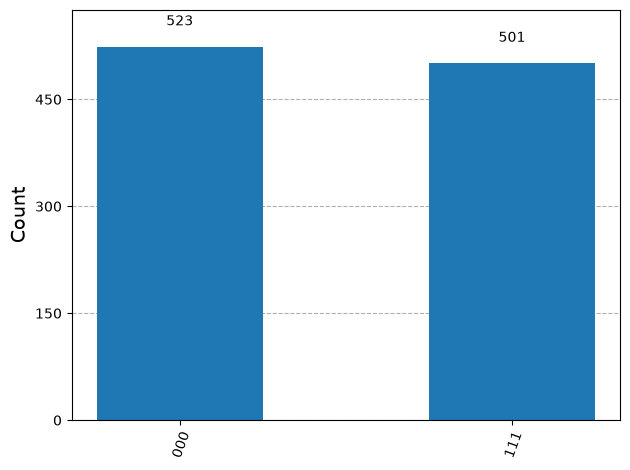

In [44]:
from qiskit.primitives import StatevectorSampler
from qiskit.visualization import plot_histogram

%matplotlib inline
qc.measure_all()

sampler = StatevectorSampler()
result = sampler.run([qc], shots=1024).result()

counts = result[0].data.meas.get_counts()
plot_histogram(counts)
plt.show()

In [45]:
qc_b = QuantumCircuit(4)
qc_b.x(3)
qc_b.draw()

q_0: ─────
          
q_1: ─────
          
q_2: ─────
     ┌───┐
q_3: ┤ X ├
     └───┘

In [46]:
from qiskit.circuit.library import QFT

qft = QFT(4)
qc_b.append(qft, [0, 1, 2, 3])
qc_b.draw()
qc_b.measure_all()

C:\Users\pasca\AppData\Local\Temp\ipykernel_11404\1979671290.py:3: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(4)


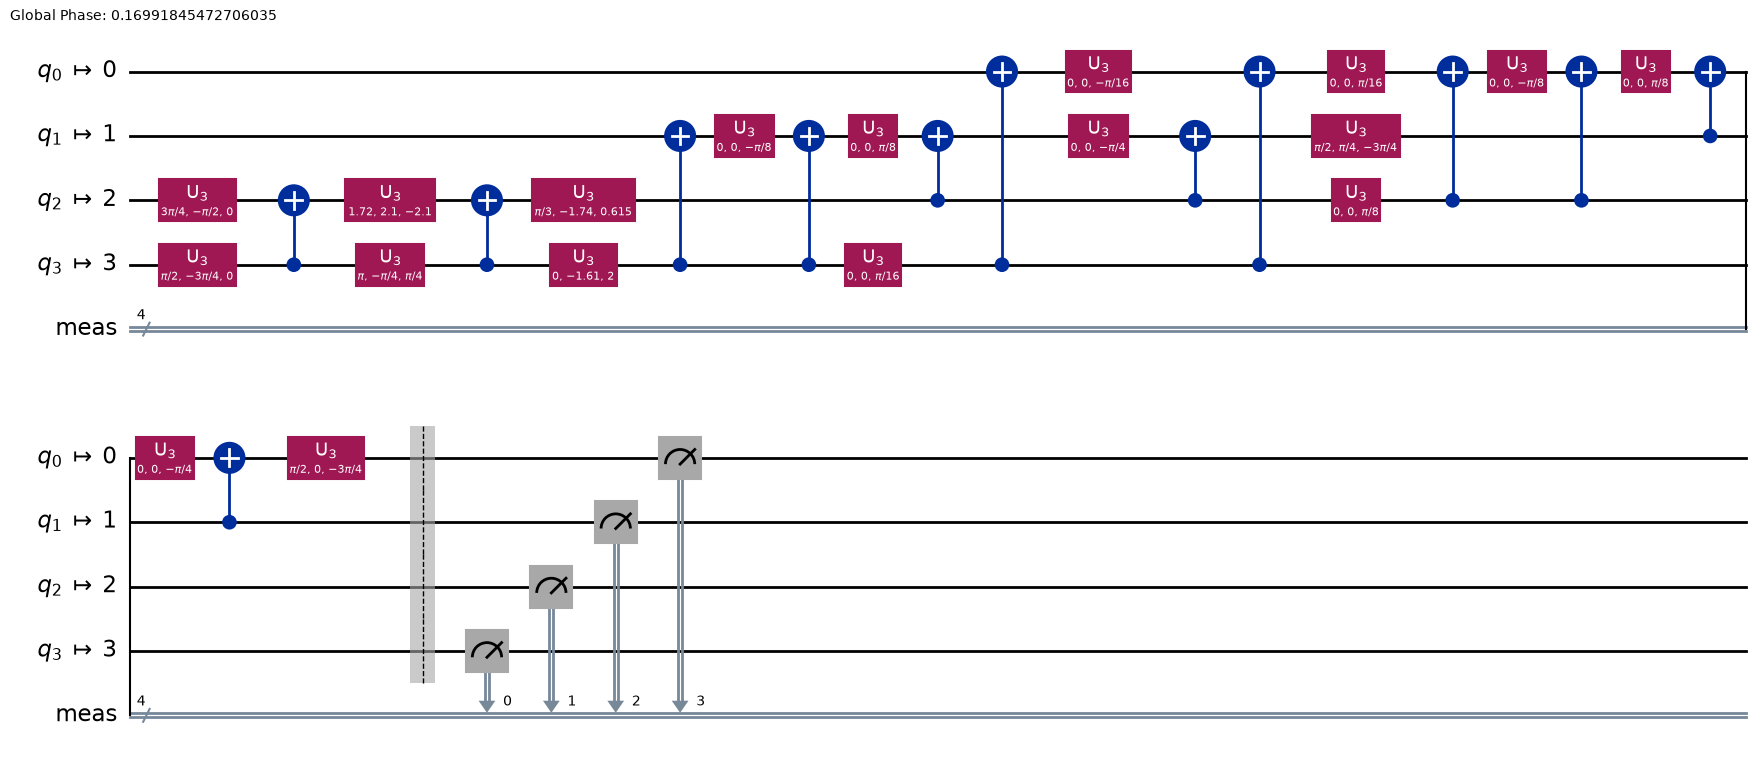

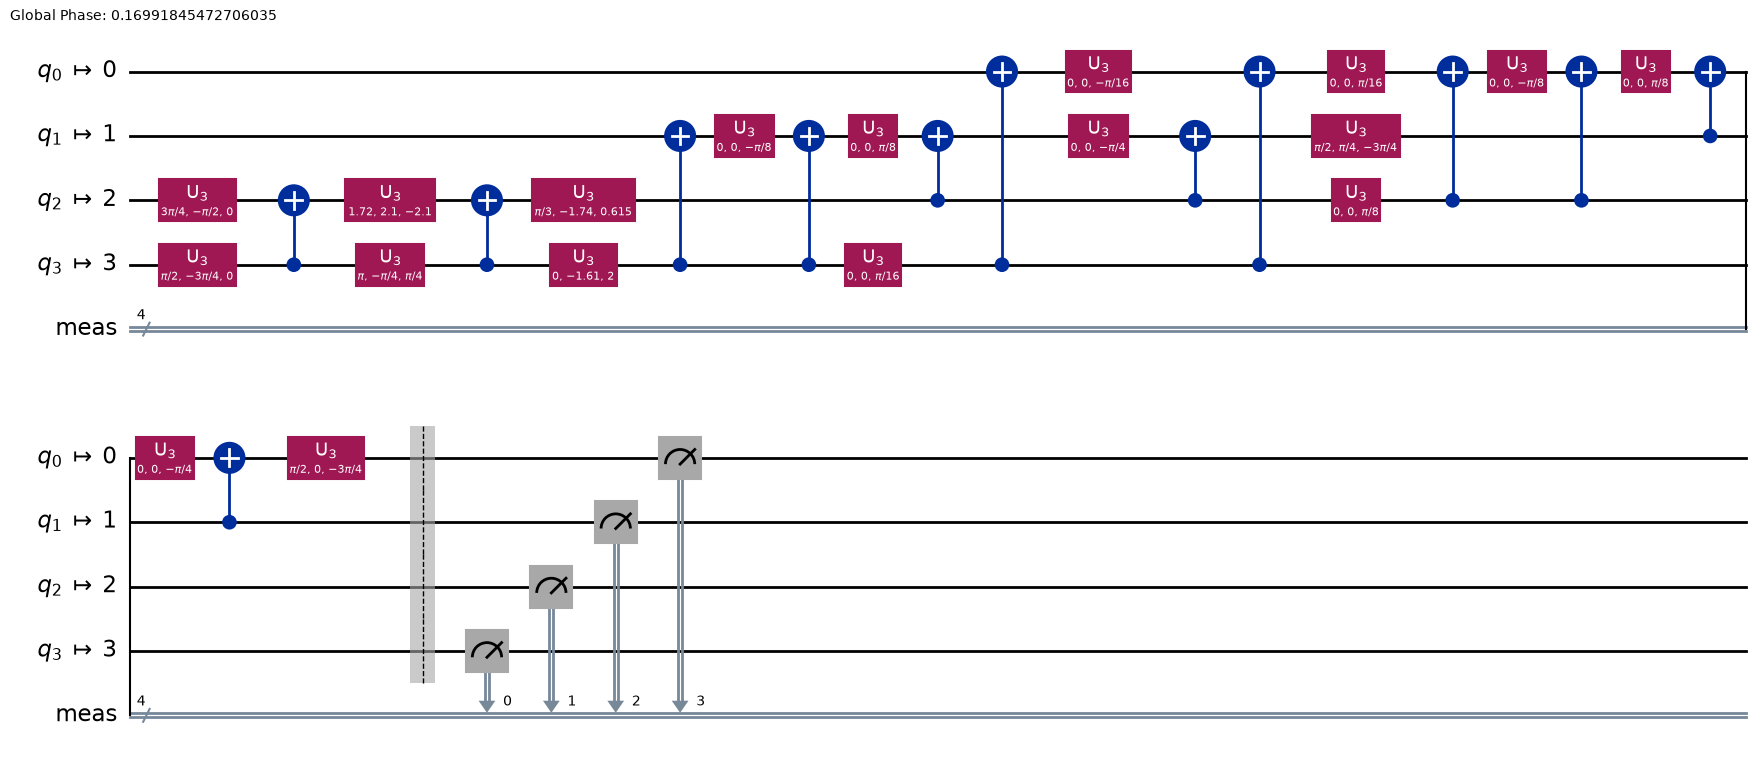

In [47]:
transpiled_qc = transpile(qc_b, basis_gates=["u3", "cx"])
transpiled_qc.draw("mpl")

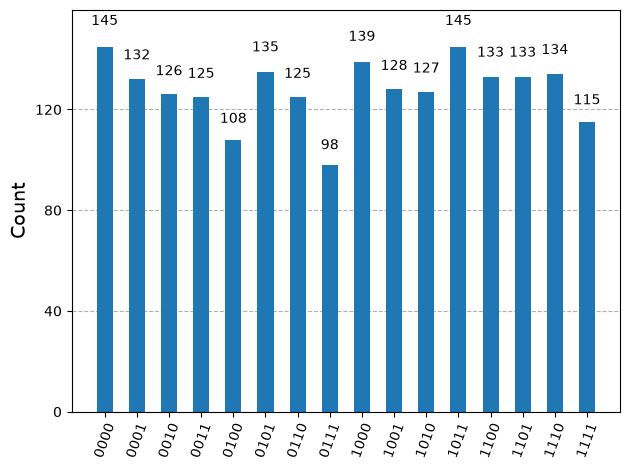

In [48]:
from qiskit_aer import AerSimulator

simulator = AerSimulator()

job = simulator.run(transpiled_qc, shots=2048)
result = job.result()

counts = result.get_counts()

plot_histogram(counts)

plt.show()

In [49]:
from qiskit.quantum_info import Statevector

qc_no_meas = QuantumCircuit(4)
qc_no_meas.x(3)

qc_no_meas.append(QFT(4), [0, 1, 2, 3])

sv = Statevector(qc_no_meas)
print(sv)

Statevector([ 0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j,  0.25+0.j,
             -0.25+0.j,  0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j,
              0.25+0.j, -0.25+0.j,  0.25+0.j, -0.25+0.j,  0.25+0.j,
             -0.25+0.j],
            dims=(2, 2, 2, 2))


C:\Users\pasca\AppData\Local\Temp\ipykernel_11404\789143912.py:6: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qc_no_meas.append(QFT(4), [0, 1, 2, 3])


In [50]:
qc_c = QuantumCircuit(4)
qubits = [0, 1, 2, 3]
for i in qubits:
    qc_c.h(i)
qc_c.draw()

┌───┐
q_0: ┤ H ├
     ├───┤
q_1: ┤ H ├
     ├───┤
q_2: ┤ H ├
     ├───┤
q_3: ┤ H ├
     └───┘

C:\Users\pasca\AppData\Local\Temp\ipykernel_11404\1425525519.py:1: DeprecationWarning: The class ``qiskit.circuit.library.basis_change.qft.QFT`` is deprecated as of Qiskit 2.1. It will be removed in Qiskit 3.0. ('Use qiskit.circuit.library.QFTGate or qiskit.synthesis.qft.synth_qft_full instead, for access to all previous arguments.',)
  qft = QFT(4)


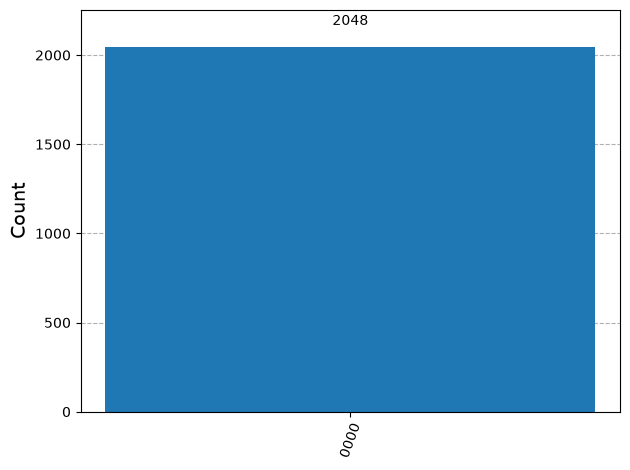

In [51]:
qft = QFT(4)
qc_c.append(qft, [0, 1, 2, 3])
qc_c.draw()
qc_c.measure_all()

transpiled_qc_c = transpile(qc_c, basis_gates=["u3", "cx"])

simulator = AerSimulator()

job_c = simulator.run(transpiled_qc_c, shots=2048)
result_c = job_c.result()

counts = result_c.get_counts()

plot_histogram(counts)

plt.show()